c:\Users\miran\AppData\Local\Programs\Python\Python311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data.myhome.go.kr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


총 374건의 데이터를 수집했습니다.
데이터 🟠정제 완료: 모든 {}를 빈칸으로 변경했습니다.


C:\Users\miran\AppData\Local\Temp\ipykernel_49308\3951617746.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='houseTyNm', y='suplyPrvuseAr', palette='Set3', ax=axes[0,1])


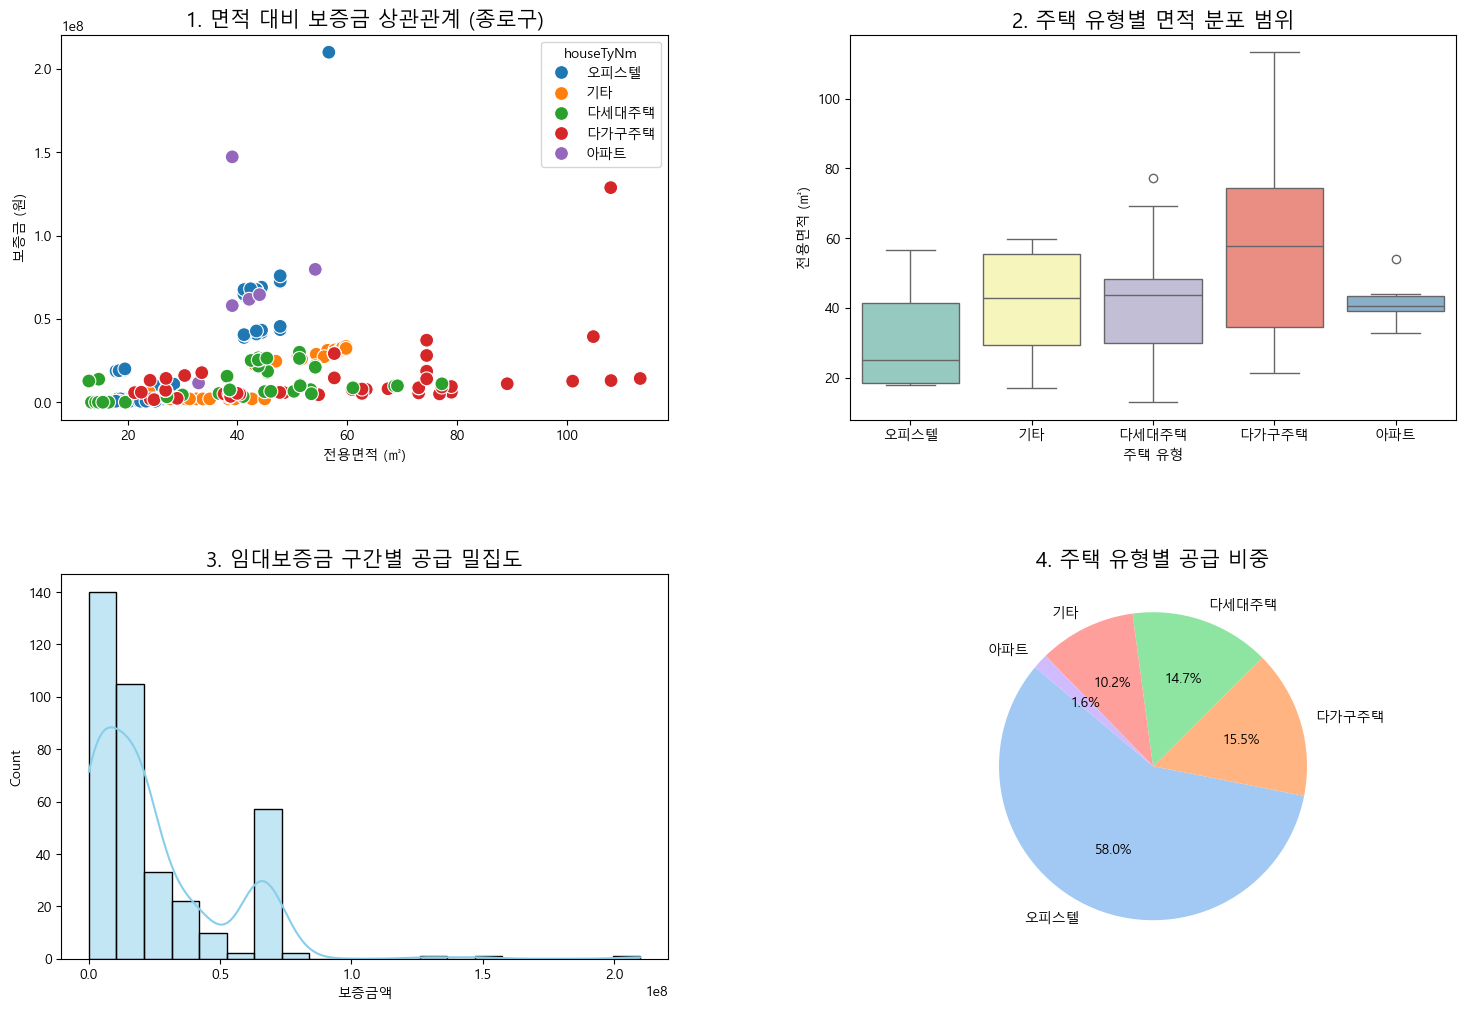

In [7]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 수집
base_url = "https://data.myhome.go.kr:443/rentalHouseList" 
service_key = "6114f483bd6368bb21a7995881e36487d6baeae732d0dcdd3c719842dd0d35ed"

params = {
    'ServiceKey': service_key,
    'brtcCode': '11', 
    'signguCode': '110', 
    'numOfRows': '1000', 
    'pageNo': '1',    
}

response = requests.get(base_url, params=params, verify=False)
data = response.json()

if 'hsmpList' in data:
    df = pd.DataFrame(data['hsmpList'])
    print(f"총 {len(df)}건의 데이터를 수집했습니다.")

    # [필수 전처리 1] 🧹 삭제 대신 {}만 빈칸("")으로 바꾸기
    # df = df.map(lambda x: "" if x == {} else x)
    df = df.map(lambda x: '기타' if x == {} else x) #2️⃣
    print("데이터 🟠정제 완료: 모든 {}를 빈칸으로 변경했습니다.") #기타로
 
    # [필수 전처리 2] 🧹 숫자형으로 데이터 타입 변환 [공급전용면적, 기본임대보증금]
    df['suplyPrvuseAr'] = pd.to_numeric(df['suplyPrvuseAr'], errors='coerce') #공급전용면적
    df['bassRentGtn'] = pd.to_numeric(df['bassRentGtn'], errors='coerce') #기본임대보증금

    # 2. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3) #그래프 사이간격 h위아래, 좌우

    # (1) 산점도 (Scatter Plot): 면적과 보증금의 상관관계 🍋x=axes[0,0] 위치
    sns.scatterplot(data=df, x='suplyPrvuseAr', y='bassRentGtn', hue='houseTyNm', s=100, ax=axes[0,0])
    axes[0,0].set_title('1. 면적 대비 보증금 상관관계 (종로구)', fontsize=15)
    axes[0,0].set_xlabel('전용면적 (㎡)')
    axes[0,0].set_ylabel('보증금 (원)')

    # (2) 박스 플롯 (Box Plot): 주택유형별 면적 분포 (격차 확인)
    sns.boxplot(data=df, x='houseTyNm', y='suplyPrvuseAr', palette='Set3', ax=axes[0,1])
    # print("2️⃣🟠어떤 유형?",df['houseTyNm'].unique()) #어떤 이름들이 있는지 눈으로 확인
    axes[0,1].set_title('2. 주택 유형별 면적 분포 범위', fontsize=15)
    axes[0,1].set_xlabel('주택 유형')
    axes[0,1].set_ylabel('전용면적 (㎡)')

    # (3) 히스토그램 (Histogram): 보증금 밀집 구간 확인
    sns.histplot(df['bassRentGtn'].dropna(), bins=20, kde=True, color='skyblue', ax=axes[1,0])
    axes[1,0].set_title('3. 임대보증금 구간별 공급 밀집도', fontsize=15)
    axes[1,0].set_xlabel('보증금액')

    # (4) 파이 차트 (Pie Chart): 공급 유형별 비중
    type_counts = df['houseTyNm'].value_counts()
    axes[1,1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
                  startangle=140, colors=sns.color_palette('pastel'))
    axes[1,1].set_title('4. 주택 유형별 공급 비중', fontsize=15)

    plt.show()
else:
    print("데이터를 불러오지 못했습니다. API 응답을 확인하세요.")